# Week 05 — Hidden Layer Lab

Goal: compare a straight-line classifier with a small neural network on the same curved dataset.

The main question:

Can a model with one straight recipe solve a curved two-class problem, or do we need learned intermediate features?

In [99]:
from pathlib import Path


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing pyproject.toml.")


project_root = find_project_root(Path.cwd()).resolve()

In [100]:
RANDOM_STATE = 42
TEST_SIZE = 0.2
LEARNING_RATE = 0.01

## Generate the moon-shaped dataset

Each row has two input features:

- `x_position`
- `y_position`

The answer column is:

- `class_label`

Expected shape: `(500, 3)` because there are 500 rows and 3 columns.

In [101]:
import pandas as pd
from sklearn.datasets import make_moons

data_path = project_root / "data" / "generated" / "week-05-moons.csv"
data_path.parent.mkdir(parents=True, exist_ok=True)

X, y = make_moons(
    n_samples=500,
    noise=0.25,
    random_state=RANDOM_STATE,
)

points = pd.DataFrame(
    {
        "x_position": X[:, 0],
        "y_position": X[:, 1],
        "class_label": y,
    }
)

points.to_csv(data_path, index=False)

print(points.shape)
points.head()

(500, 3)


,x_position,y_position,class_label
0,0.830948,-0.296546,1
1,1.088387,0.899693,0
2,1.135634,-0.462935,1
3,-0.082277,1.059718,0
4,0.443047,1.418977,0


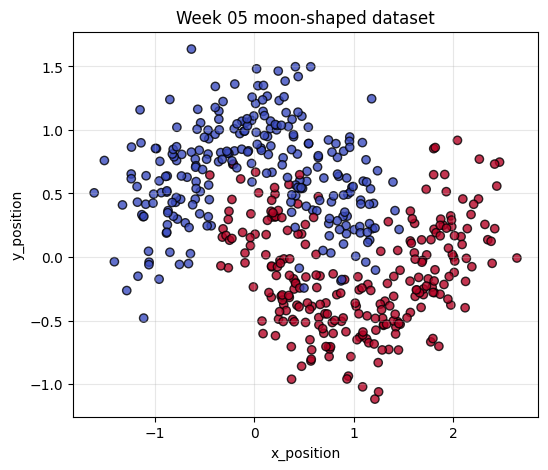

In [102]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 5))

scatter = ax.scatter(
    points["x_position"],
    points["y_position"],
    c=points["class_label"],
    cmap="coolwarm",
    edgecolor="black",
    alpha=0.8,
)

ax.set_title("Week 05 moon-shaped dataset")
ax.set_xlabel("x_position")
ax.set_ylabel("y_position")
ax.grid(True, alpha=0.3)

plt.show()

## Raw data observation

The two classes form curved moon shapes.

A single straight line may classify many points correctly, but it probably cannot cleanly separate the two curves.

In [103]:
from sklearn.model_selection import train_test_split

features = points[["x_position", "y_position"]].to_numpy()
labels = points["class_label"].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    features,
    labels,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=labels,
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (400, 2)
X_test: (100, 2)
y_train: (400,)
y_test: (100,)


## Convert arrays to tensors

`X_train` is a matrix of input positions with shape `(400, 2)`.

`y_train` is one class label per row. We reshape it to `(400, 1)` so it matches the model output shape.

In [104]:
import torch

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1)

print("X_train_tensor:", X_train_tensor.shape, X_train_tensor.dtype)
print("y_train_tensor:", y_train_tensor.shape, y_train_tensor.dtype)
print("X_test_tensor:", X_test_tensor.shape, X_test_tensor.dtype)
print("y_test_tensor:", y_test_tensor.shape, y_test_tensor.dtype)

X_train_tensor: torch.Size([400, 2]) torch.float32
y_train_tensor: torch.Size([400, 1]) torch.float32
X_test_tensor: torch.Size([100, 2]) torch.float32
y_test_tensor: torch.Size([100, 1]) torch.float32


In [105]:
import torch.nn as nn

torch.manual_seed(RANDOM_STATE)

linear_model = nn.Linear(in_features=2, out_features=1)

for name, parameter in linear_model.named_parameters():
    print(name, parameter.shape)

with torch.no_grad():
    sample_logits = linear_model(X_train_tensor[:5])

print(f"sample_logits shape: {sample_logits.shape}")
sample_logits

weight torch.Size([1, 2])
bias torch.Size([1])
sample_logits shape: torch.Size([5, 1])


tensor([[ 0.3178],
        [ 0.6995],
        [-0.3307],
        [-0.4307],
        [ 0.1584]])

## Logits and sigmoid

The linear model outputs logits.

A logit is a raw score. Sigmoid turns each logit into a probability between `0` and `1`.

Positive logits become probabilities above `0.5`; negative logits become probabilities below `0.5`.

In [106]:
torch.sigmoid(sample_logits)

tensor([[0.5788],
        [0.6681],
        [0.4181],
        [0.3940],
        [0.5395]])

## Train the linear baseline

The linear model can only learn one direct recipe:

`score = weight_1 * x_position + weight_2 * y_position + bias`

Because the moons are curved, this model may improve for many epochs but still hit a shape limit.

In [107]:
loss_function = nn.BCEWithLogitsLoss()

linear_optimizer = torch.optim.SGD(linear_model.parameters(), lr=LEARNING_RATE)

linear_losses: list[float] = []

for epoch in range(2000):
    linear_model.train()

    logits = linear_model(X_train_tensor)
    loss = loss_function(logits, y_train_tensor)

    linear_optimizer.zero_grad()
    loss.backward()
    linear_optimizer.step()

    linear_losses.append(float(loss.item()))

    if epoch % 200 == 0:
        print(f"epoch {epoch}, loss {loss.item():.4f}")

print(f"Final linear loss: {linear_losses[-1]:.4f}")

epoch 0, loss 0.7132
epoch 200, loss 0.5880
epoch 400, loss 0.5150
epoch 600, loss 0.4691
epoch 800, loss 0.4380
epoch 1000, loss 0.4157
epoch 1200, loss 0.3990
epoch 1400, loss 0.3860
epoch 1600, loss 0.3756
epoch 1800, loss 0.3670
Final linear loss: 0.3599


In [108]:
def binary_accuracy_from_logits(logits: torch.Tensor, labels: torch.Tensor) -> float:
    probabilities = torch.sigmoid(logits)
    predictions = (probabilities >= 0.5).float()
    accuracy = (predictions == labels).float().mean()
    return float(accuracy.item())


linear_model.eval()

with torch.no_grad():
    train_logits = linear_model(X_train_tensor)
    test_logits = linear_model(X_test_tensor)

    linear_train_accuracy = binary_accuracy_from_logits(train_logits, y_train_tensor)
    linear_test_accuracy = binary_accuracy_from_logits(test_logits, y_test_tensor)
    linear_final_loss = loss_function(train_logits, y_train_tensor)

print(f"linear train accuracy: {linear_train_accuracy:.3f}")
print(f"linear test accuracy: {linear_test_accuracy:.3f}")
print(f"linear final train loss: {linear_final_loss.item():.4f}")

linear train accuracy: 0.825
linear test accuracy: 0.810
linear final train loss: 0.3599


## Linear baseline findings

The linear model reached:

- train accuracy: `0.848`
- test accuracy: `0.820`
- final train loss: `0.3238`

Because both train and test accuracy are limited, this looks more like a model-capacity limit than overfitting.

Next we need to train an MLP with one hidden layer and compare whether extra learned features help bend the decision boundary.

In [109]:
HIDDEN_UNITS = 16

torch.manual_seed(RANDOM_STATE)

mlp_model = nn.Sequential(
    nn.Linear(in_features=2, out_features=HIDDEN_UNITS),
    nn.ReLU(),
    nn.Linear(in_features=HIDDEN_UNITS, out_features=1),
)

for name, parameter in mlp_model.named_parameters():
    print(name, parameter.shape)

with torch.no_grad():
    sample_mlp_logits = mlp_model(X_train_tensor[:5])

print(f"sample_mlp_logits shape: {sample_mlp_logits.shape}")
print(sample_mlp_logits)

0.weight torch.Size([16, 2])
0.bias torch.Size([16])
2.weight torch.Size([1, 16])
2.bias torch.Size([1])
sample_mlp_logits shape: torch.Size([5, 1])
tensor([[ 0.3598],
        [ 0.4573],
        [-0.1526],
        [-0.0877],
        [ 0.3141]])


## MLP as a chain of functions

The neural-network language is a metaphor.

In code, this model is a chain of functions:

`logit = linear_2(relu(linear_1(input_point)))`

The first linear function maps each 2-number point into 16 learned intermediate numbers.

Those 16 numbers are called hidden units, but they are not literal neurons. A more concrete name is:

**16 learned intermediate features**

The first layer has shape `[16, 2]` because it creates 16 outputs, and each output uses both input features:

- `x_position`
- `y_position`

So the first layer has:

- `16 * 2 = 32` weights
- `16` biases

Each hidden output follows this pattern:

`hidden_raw_i = weight_ix * x_position + weight_iy * y_position + bias_i`

Then `ReLU` changes negative hidden values to `0`.

`ReLU` does not appear in `named_parameters()` because it has no learned parameters. It is still layer index `1` inside `nn.Sequential`.

### Connection-first Pyplot diagram

This diagram shows the model as values connected by weighted operations.

The circles are values:

- 2 input values
- 16 intermediate hidden values
- 1 output logit

The lines are weighted operations.

Each line represents both:

- a stored learned weight
- the multiplication that uses it, such as `weight_ix * x_position`

A full hidden output also adds its bias:

`hidden_raw_i = weight_ix * x_position + weight_iy * y_position + bias_i`

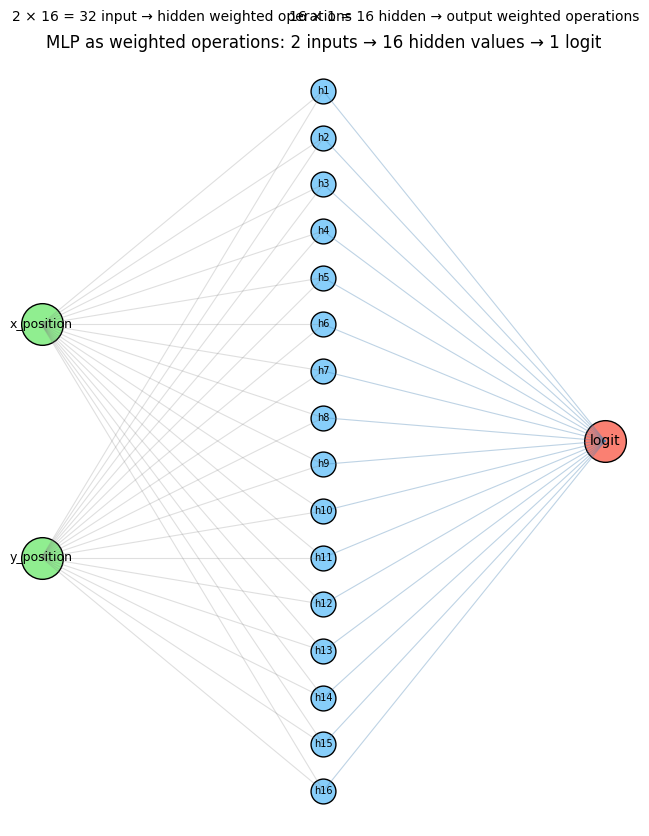

saved connection diagram to: C:\Users\giloz\dev\intuitive_understanding_machine_learning\artifacts\week-05-small-neural-networks\mlp_connections.png


In [110]:
from matplotlib.axes import Axes
from matplotlib.figure import Figure

connection_plot_path = (
    project_root / "artifacts" / "week-05-small-neural-networks" / "mlp_connections.png"
)
connection_plot_path.parent.mkdir(parents=True, exist_ok=True)

figure: Figure
axis: Axes
figure, axis = plt.subplots(figsize=(8, 10))

input_nodes: list[tuple[str, float, float]] = [
    ("x_position", 0.0, 0.65),
    ("y_position", 0.0, 0.35),
]

hidden_y_positions: list[float] = [
    0.95 - index * (0.90 / (HIDDEN_UNITS - 1)) for index in range(HIDDEN_UNITS)
]

hidden_nodes: list[tuple[str, float, float]] = [
    (f"h{index + 1}", 1.0, y_position)
    for index, y_position in enumerate(hidden_y_positions)
]

output_node: tuple[str, float, float] = ("logit", 2.0, 0.5)

for _, input_x, input_y in input_nodes:
    for _, hidden_x, hidden_y in hidden_nodes:
        axis.plot(
            [input_x, hidden_x],
            [input_y, hidden_y],
            color="gray",
            alpha=0.25,
            linewidth=0.8,
        )

for _, hidden_x, hidden_y in hidden_nodes:
    axis.plot(
        [hidden_x, output_node[1]],
        [hidden_y, output_node[2]],
        color="steelblue",
        alpha=0.35,
        linewidth=0.8,
    )

for label, x_position, y_position in input_nodes:
    axis.scatter(x_position, y_position, s=900, color="lightgreen", edgecolor="black")
    axis.text(x_position, y_position, label, ha="center", va="center", fontsize=9)

for label, x_position, y_position in hidden_nodes:
    axis.scatter(x_position, y_position, s=320, color="lightskyblue", edgecolor="black")
    axis.text(x_position, y_position, label, ha="center", va="center", fontsize=7)

axis.scatter(output_node[1], output_node[2], s=900, color="salmon", edgecolor="black")
axis.text(
    output_node[1],
    output_node[2],
    output_node[0],
    ha="center",
    va="center",
    fontsize=10,
)

axis.text(0.5, 1.04, "2 × 16 = 32 input → hidden weighted operations", ha="center")
axis.text(1.5, 1.04, "16 × 1 = 16 hidden → output weighted operations", ha="center")
axis.set_title("MLP as weighted operations: 2 inputs → 16 hidden values → 1 logit")
axis.axis("off")

figure.savefig(connection_plot_path, dpi=160, bbox_inches="tight")
plt.show()

print(f"saved connection diagram to: {connection_plot_path}")

In [111]:
mlp_model

Sequential(
  (0): Linear(in_features=2, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=1, bias=True)
)

## Sequential layer numbering

`nn.Sequential` numbers every layer in order:

- layer `0`: first `Linear`
- layer `1`: `ReLU`
- layer `2`: second `Linear`

`named_parameters()` skips layer `1` because `ReLU` has no weights or biases to train.

That is why the printed parameter names jump from `0.bias` to `2.weight`.

In [112]:
first_layer = mlp_model[0]
relu_layer = mlp_model[1]

with torch.no_grad():
    hidden_raw = first_layer(X_train_tensor[:5])
    hidden_after_relu = relu_layer(hidden_raw)

print("input shape:", X_train_tensor[:5].shape)
print("hidden raw shape:", hidden_raw.shape)
print("hidden after ReLU shape:", hidden_after_relu.shape)
print(hidden_after_relu)

input shape: torch.Size([5, 2])
hidden raw shape: torch.Size([5, 16])
hidden after ReLU shape: torch.Size([5, 16])
tensor([[1.0293, 0.0000, 0.0000, 0.0000, 1.2998, 1.4038, 0.7938, 0.3305, 0.9351,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.8755, 1.3819],
        [1.4111, 0.0000, 0.0000, 0.0000, 1.1282, 1.5641, 0.9214, 0.3307, 1.0707,
         0.0000, 0.0000, 0.1583, 0.0000, 0.0000, 0.5282, 1.1706],
        [0.3808, 0.6643, 0.0037, 1.0140, 0.0000, 0.0637, 0.0000, 0.0000, 0.0000,
         0.2312, 0.5590, 1.1861, 0.7466, 0.0000, 0.0000, 0.0000],
        [0.2809, 0.4878, 0.0000, 0.8806, 0.0000, 0.0837, 0.0000, 0.0000, 0.0000,
         0.1577, 0.5516, 1.0441, 0.7799, 0.0000, 0.1069, 0.0000],
        [0.8700, 0.0000, 0.0000, 0.0000, 1.1717, 1.2475, 0.6617, 0.2518, 0.7971,
         0.0000, 0.0000, 0.0099, 0.0000, 0.0000, 0.8917, 1.2538]])


In [113]:
first_layer = mlp_model[0]

print("first layer weights:")
print(first_layer.weight.shape)
print(first_layer.weight)

print("first layer biases:")
print(first_layer.bias.shape)
print(first_layer.bias)

first layer weights:
torch.Size([16, 2])
Parameter containing:
tensor([[ 0.5406,  0.5869],
        [-0.1657,  0.6496],
        [-0.1549,  0.1427],
        [-0.3443,  0.4153],
        [ 0.6233, -0.5188],
        [ 0.6146,  0.1323],
        [ 0.5224,  0.0958],
        [ 0.3410, -0.0998],
        [ 0.5451,  0.1045],
        [-0.3301,  0.1802],
        [-0.3258, -0.0829],
        [-0.2872,  0.4691],
        [-0.5582, -0.3260],
        [-0.1997, -0.4252],
        [ 0.0667, -0.6984],
        [ 0.6386, -0.6007]], requires_grad=True)
first layer biases:
torch.Size([16])
Parameter containing:
tensor([ 0.5459,  0.1177, -0.2296,  0.4370,  0.1102,  0.5713,  0.0773, -0.2230,
         0.1900, -0.1918,  0.2976,  0.6313,  0.4087, -0.3091,  0.4082,  0.1265],
       requires_grad=True)


In [114]:
mlp_optimizer = torch.optim.Adam(mlp_model.parameters(), lr=LEARNING_RATE)

mlp_losses: list[float] = []

for epoch in range(2000):
    mlp_model.train()

    logits = mlp_model(X_train_tensor)
    loss = loss_function(logits, y_train_tensor)

    mlp_optimizer.zero_grad()
    loss.backward()
    mlp_optimizer.step()

    mlp_losses.append(float(loss.item()))

    if epoch % 200 == 0:
        print(f"epoch {epoch}, loss {loss.item():.4f}")

print(f"final MLP loss: {mlp_losses[-1]:.4f}")

epoch 0, loss 0.6438
epoch 200, loss 0.1645
epoch 400, loss 0.1087
epoch 600, loss 0.0997
epoch 800, loss 0.0935
epoch 1000, loss 0.0914
epoch 1200, loss 0.0903
epoch 1400, loss 0.0894
epoch 1600, loss 0.0887
epoch 1800, loss 0.0877
final MLP loss: 0.0869


In [115]:
mlp_model.eval()

with torch.no_grad():
    mlp_train_logits = mlp_model(X_train_tensor)
    mlp_test_logits = mlp_model(X_test_tensor)

    mlp_train_accuracy = binary_accuracy_from_logits(mlp_train_logits, y_train_tensor)
    mlp_test_accuracy = binary_accuracy_from_logits(mlp_test_logits, y_test_tensor)
    mlp_final_loss = loss_function(mlp_train_logits, y_train_tensor)

print(f"MLP train accuracy: {mlp_train_accuracy:.3f}")
print(f"MLP test accuracy: {mlp_test_accuracy:.3f}")
print(f"MLP final train loss: {mlp_final_loss.item():.4f}")

MLP train accuracy: 0.960
MLP test accuracy: 0.930
MLP final train loss: 0.0869


In [116]:
comparison_path = (
    project_root
    / "artifacts"
    / "week-05-small-neural-networks"
    / "model_comparison.csv"
)
comparison_path.parent.mkdir(parents=True, exist_ok=True)

model_comparison = pd.DataFrame(
    [
        {
            "model": "linear",
            "train_accuracy": linear_train_accuracy,
            "test_accuracy": linear_test_accuracy,
            "final_loss": float(linear_final_loss.item()),
        },
        {
            "model": "mlp_16_hidden_units",
            "train_accuracy": mlp_train_accuracy,
            "test_accuracy": mlp_test_accuracy,
            "final_loss": float(mlp_final_loss.item()),
        },
    ]
)

model_comparison.to_csv(comparison_path, index=False)

print(f"saved comparison to: {comparison_path}")
model_comparison

saved comparison to: C:\Users\giloz\dev\intuitive_understanding_machine_learning\artifacts\week-05-small-neural-networks\model_comparison.csv


,model,train_accuracy,test_accuracy,final_loss
0,linear,0.825,0.81,0.359879
1,mlp_16_hidden_units,0.960,0.93,0.086871


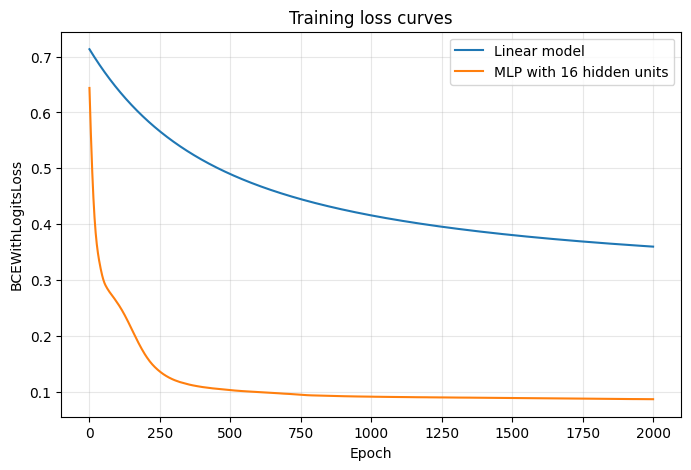

saved loss curves to: C:\Users\giloz\dev\intuitive_understanding_machine_learning\artifacts\week-05-small-neural-networks\loss_curves.png


In [117]:
loss_curves_path = (
    project_root / "artifacts" / "week-05-small-neural-networks" / "loss_curves.png"
)
loss_curves_path.parent.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(linear_losses, label="Linear model")
ax.plot(mlp_losses, label="MLP with 16 hidden units")

ax.set_title("Training loss curves")
ax.set_xlabel("Epoch")
ax.set_ylabel("BCEWithLogitsLoss")
ax.legend()
ax.grid(True, alpha=0.3)

fig.savefig(loss_curves_path, dpi=160, bbox_inches="tight")
plt.show()

print(f"saved loss curves to: {loss_curves_path}")

## Decision boundary helper

To draw a boundary, we create a grid of fake `(x_position, y_position)` points covering the plot area.

Then we ask the model for a probability at each grid point.

The black contour line marks probability `0.5`, where the model switches between class `0` and class `1`.

In [118]:
import numpy as np
from numpy.typing import NDArray

FloatArray = NDArray[np.float64]


def make_prediction_grid(
    points_df: pd.DataFrame, padding: float = 0.5, steps: int = 300
) -> tuple[FloatArray, FloatArray, FloatArray]:
    x_min = float(points_df["x_position"].min() - padding)
    x_max = float(points_df["x_position"].max() + padding)
    y_min = float(points_df["y_position"].min() - padding)
    y_max = float(points_df["y_position"].max() + padding)

    x_values = np.linspace(x_min, x_max, steps)
    y_values = np.linspace(y_min, y_max, steps)

    grid_x, grid_y = np.meshgrid(x_values, y_values)
    grid_points = np.column_stack([grid_x.ravel(), grid_y.ravel()])

    return grid_x, grid_y, grid_points


def predict_grid_probabilities(model: nn.Module, grid_points: FloatArray) -> FloatArray:
    model.eval()

    grid_tensor = torch.tensor(grid_points, dtype=torch.float32)

    with torch.no_grad():
        grid_logits = model(grid_tensor)
        grid_probabilities = torch.sigmoid(grid_logits)

    return grid_probabilities.numpy().reshape(300, 300)

## Linear decision boundary

The linear model uses one direct recipe, so its boundary should be mostly straight.

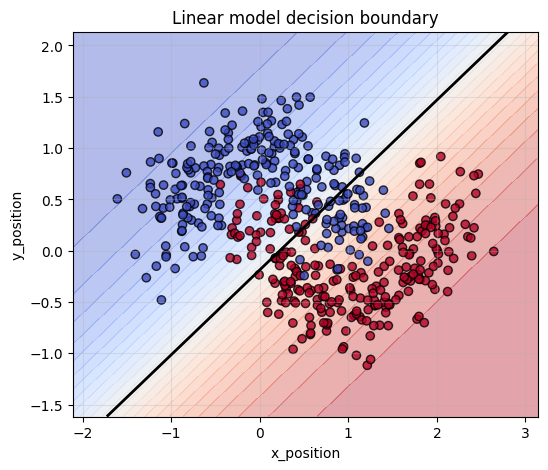

saved linear boundary to: C:\Users\giloz\dev\intuitive_understanding_machine_learning\artifacts\week-05-small-neural-networks\linear_boundary.png


In [119]:
linear_boundary_path = (
    project_root / "artifacts" / "week-05-small-neural-networks" / "linear_boundary.png"
)

grid_x, grid_y, grid_points = make_prediction_grid(points)
linear_grid_probabilities = predict_grid_probabilities(linear_model, grid_points)

fig, ax = plt.subplots(figsize=(6, 5))

ax.contourf(
    grid_x,
    grid_y,
    linear_grid_probabilities,
    levels=30,
    cmap="coolwarm",
    alpha=0.4,
)

ax.contour(
    grid_x,
    grid_y,
    linear_grid_probabilities,
    levels=[0.5],
    colors="black",
    linewidths=2,
)

ax.scatter(
    points["x_position"],
    points["y_position"],
    c=points["class_label"],
    cmap="coolwarm",
    edgecolor="black",
    alpha=0.8,
)

ax.set_title("Linear model decision boundary")
ax.set_xlabel("x_position")
ax.set_ylabel("y_position")
ax.grid(True, alpha=0.3)

fig.savefig(linear_boundary_path, dpi=160, bbox_inches="tight")
plt.show()

print(f"saved linear boundary to: {linear_boundary_path}")

### Linear boundary observation

The linear boundary is mostly straight and cuts awkwardly across the curved moon shapes.

This makes the model look “gross” on this dataset: it can classify many points, but it cannot bend around the moons.

## MLP decision boundary

The MLP uses the same grid, but its function is:

`logit = linear_2(relu(linear_1(input_point)))`

Because of the hidden intermediate values and ReLU, its boundary can be nonlinear.

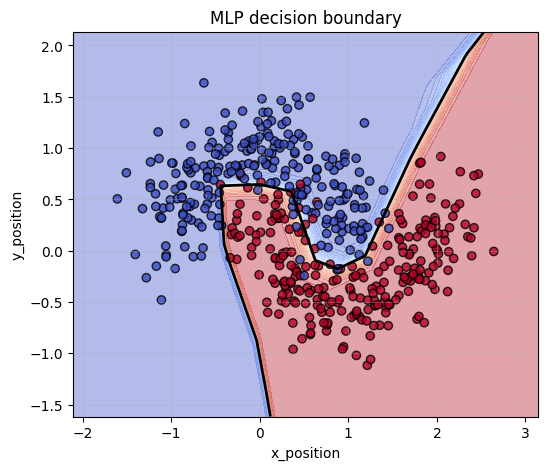

saved MLP boundary to: C:\Users\giloz\dev\intuitive_understanding_machine_learning\artifacts\week-05-small-neural-networks\mlp_boundary.png


In [120]:
mlp_boundary_path = (
    project_root / "artifacts" / "week-05-small-neural-networks" / "mlp_boundary.png"
)

grid_x, grid_y, grid_points = make_prediction_grid(points)
mlp_grid_probabilities = predict_grid_probabilities(mlp_model, grid_points)

fig, ax = plt.subplots(figsize=(6, 5))

ax.contourf(
    grid_x,
    grid_y,
    mlp_grid_probabilities,
    levels=30,
    cmap="coolwarm",
    alpha=0.4,
)

ax.contour(
    grid_x,
    grid_y,
    mlp_grid_probabilities,
    levels=[0.5],
    colors="black",
    linewidths=2,
)

ax.scatter(
    points["x_position"],
    points["y_position"],
    c=points["class_label"],
    cmap="coolwarm",
    edgecolor="black",
    alpha=0.8,
)

ax.set_title("MLP decision boundary")
ax.set_xlabel("x_position")
ax.set_ylabel("y_position")
ax.grid(True, alpha=0.3)

fig.savefig(mlp_boundary_path, dpi=160, bbox_inches="tight")
plt.show()

print(f"saved MLP boundary to: {mlp_boundary_path}")

### MLP boundary observation

The MLP boundary is not linear.

It bends around the moon shapes and covers the majority of the red/class `1` points better than the linear model.

This matches the metrics: the MLP has higher test accuracy and much lower loss.

## Current intuition checkpoint

We do not fully understand the whole geometric picture yet, but we clarified several important pieces.

A model does not output a boundary directly.

For one point:

`(x_position, y_position) -> model -> logit`

Then:

`sigmoid(logit) -> probability`

Then:

`probability >= 0.5 -> predicted class 1`

`probability < 0.5 -> predicted class 0`

The decision boundary is something we draw after asking the model about many fake grid points. It is the line where the probability is `0.5`.

The linear model has one direct formula, so its boundary is straight.

The MLP first creates 16 intermediate values. Each hidden unit uses the same formula template, but with different learned weights and bias:

`hidden_i = ReLU(weight_ix * x_position + weight_iy * y_position + bias_i)`

Then the output layer combines those 16 hidden values into one final logit.

Current understanding:

- ReLU can turn a hidden value off by making it `0`.
- Different hidden units have different learned weights and biases.
- The output layer learns how much each hidden value should add or subtract from the final logit.
- The MLP fits the moon data better than the linear model.

Still unclear:

- how to visualize the exact way many ReLU pieces combine into the final curved-looking boundary
- how each hidden unit’s contribution relates to visible bends in the final boundary

Important correction:

One visible bend in the final decision boundary does not necessarily correspond to exactly one hidden unit. The boundary is the result of all hidden contributions mixed together.

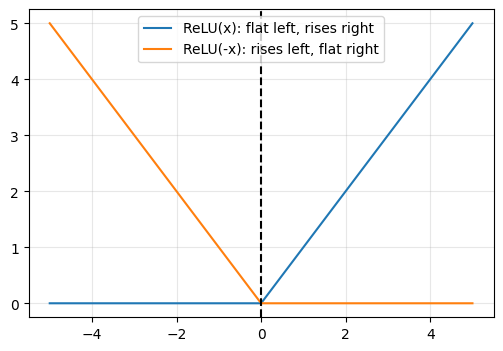

In [121]:
x_values = np.linspace(-5, 5, 200)

relu_right = np.maximum(0, x_values)
relu_left = np.maximum(0, -x_values)

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(x_values, relu_right, label="ReLU(x): flat left, rises right")
ax.plot(x_values, relu_left, label="ReLU(-x): rises left, flat right")

ax.axvline(0, color="black", linestyle="--")
ax.legend()
ax.grid(True, alpha=0.3)

plt.show()

## Hidden unit challenge prediction

I will compare:

   - 4 hidden units
   - 16 hidden units
   - 64 hidden units

My prediction:

More hidden units may improve the model because they give the MLP more intermediate values to combine.

But more hidden units will not always be better. A larger model may overfit, or the extra units may not help much once the dataset is already fitted well.

I expect 16 or 64 hidden units to perform better than 4, but I do not expect 64 to be dramatically better than 16.

In [122]:
def train_mlp_with_hidden_units(
    hidden_units: int, epochs: int = 2000
) -> dict[str, float]:
    torch.manual_seed(RANDOM_STATE)

    model = nn.Sequential(
        nn.Linear(in_features=2, out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=1),
    )

    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    losses: list[float] = []

    for epoch in range(epochs):
        model.train()

        logits = model(X_train_tensor)
        loss = loss_function(logits, y_train_tensor)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(float(loss.item()))

    model.eval()

    with torch.no_grad():
        train_logits = model(X_train_tensor)
        test_logits = model(X_test_tensor)

        train_accuracy = binary_accuracy_from_logits(train_logits, y_train_tensor)
        test_accuracy = binary_accuracy_from_logits(test_logits, y_test_tensor)
        final_loss = loss_function(train_logits, y_train_tensor)

    return {
        "hidden_units": float(hidden_units),
        "train_accuracy": train_accuracy,
        "test_accuracy": test_accuracy,
        "final_loss": float(final_loss.item()),
    }

In [123]:
hidden_unit_results = [
    train_mlp_with_hidden_units(hidden_units) for hidden_units in [4, 16, 64]
]

hidden_unit_comparison = pd.DataFrame(hidden_unit_results)

hidden_unit_comparison

,hidden_units,train_accuracy,test_accuracy,final_loss
0,4.0,0.8725,0.85,0.266921
1,16.0,0.9600,0.93,0.086871
2,64.0,0.9625,0.93,0.077676


## Hidden unit challenge result

   Results:

   - 4 hidden units: test accuracy `0.85`, final loss `0.266921`
   - 16 hidden units: test accuracy `0.93`, final loss `0.086871`
   - 64 hidden units: test accuracy `0.93`, final loss `0.077676`

   My prediction was mostly correct.

   Increasing from 4 to 16 hidden units helped a lot. Increasing from 16 to 64 lowered training loss slightly, but did not improve
 test accuracy.

   Conclusion: more hidden units can help, but more is not automatically better once the model already has enough capacity for this
 dataset.

In [124]:
hidden_unit_challenge_path = (
    project_root
    / "artifacts"
    / "week-05-small-neural-networks"
    / "hidden_unit_challenge.csv"
)

hidden_unit_comparison.to_csv(hidden_unit_challenge_path, index=False)

print(f"saved hidden unit challenge to: {hidden_unit_challenge_path}")
hidden_unit_comparison

saved hidden unit challenge to: C:\Users\giloz\dev\intuitive_understanding_machine_learning\artifacts\week-05-small-neural-networks\hidden_unit_challenge.csv


,hidden_units,train_accuracy,test_accuracy,final_loss
0,4.0,0.8725,0.85,0.266921
1,16.0,0.9600,0.93,0.086871
2,64.0,0.9625,0.93,0.077676


In [125]:
required_paths = [
    project_root / "data" / "generated" / "week-05-moons.csv",
    project_root / "artifacts" / "week-05-small-neural-networks" / "linear_boundary.png",
    project_root / "artifacts" / "week-05-small-neural-networks" / "mlp_boundary.png",
    project_root / "artifacts" / "week-05-small-neural-networks" / "model_comparison.csv",
    project_root / "artifacts" / "week-05-small-neural-networks" / "loss_curves.png",
    project_root / "artifacts" / "week-05-small-neural-networks" / "hidden_unit_challenge.csv",
]

for path in required_paths:
    print(f"{'OK' if path.exists() else 'MISSING'} - {path.relative_to(project_root)}")

OK - data\generated\week-05-moons.csv
OK - artifacts\week-05-small-neural-networks\linear_boundary.png
OK - artifacts\week-05-small-neural-networks\mlp_boundary.png
OK - artifacts\week-05-small-neural-networks\model_comparison.csv
OK - artifacts\week-05-small-neural-networks\loss_curves.png
OK - artifacts\week-05-small-neural-networks\hidden_unit_challenge.csv
